In [2]:
import torch
from pathlib import Path
from torchvision.utils import make_grid
from types import SimpleNamespace
from senn.utils.stability_white_noise import *
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
from senn.models import *
from senn.models.senn import SENN
from senn.models.parameterizers import ConvParameterizer
from senn.models.conceptizers import IdentityConceptizer
from senn.models.aggregators import SumAggregator

In [4]:
plt.style.use('seaborn-v0_8-talk')

## Load data and create perturbed images

In [5]:
config = {
    "train": False,
    "conceptizer": "IdentityConceptizer",
    "image_size": 28,
    "concept_dim": 1,
    "parameterizer": "ConvParameterizer",
    "cl_sizes": [1, 10, 20],
    "hidden_sizes": [320, 7840],
    "num_concepts": 784,
    "num_classes": 10,
    "dropout": 0.5,
    "aggregator": "SumAggregator",
    "device": "cpu",
    "lr": 2e-4,
    "epochs": 10,
    "robustness_loss": "mnist_robustness_loss",
    "robust_reg": 1e-2,
    "concept_reg": 1,
    "print_freq": 100,
    "exp_name": "IdentityConc_lambda1e-2_c5_seed29",
    "dataloader": "fashion_mnist",
    "data_path": "datasets/data/fashion_mnist_data",
    "batch_size" : 200,
    "sparsity_reg" : 2e-5,
    "eval_freq" : 270,
    "manual_seed": 29
  }
config = SimpleNamespace(**config)

In [6]:
from senn.datasets.dataloaders import get_dataloader
train_dl, val_dl, test_dl = get_dataloader(config)

x_b, y_b = next(iter(test_dl))

In [7]:
mask_sneaker = (y_b == 7)
x_target = x_b[mask_sneaker][4]
print(x_target.shape)

torch.Size([1, 28, 28])


In [8]:
neighbors = x_target.unsqueeze(0).repeat(10, 1, 1, 1)
print(neighbors.shape)

torch.Size([10, 1, 28, 28])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.81019837..2.0226629].


(np.float64(-0.5), np.float64(331.5), np.float64(31.5), np.float64(-0.5))

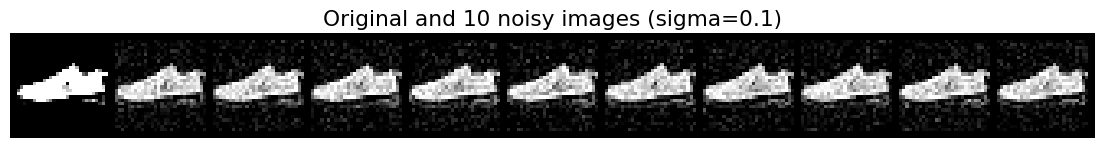

In [9]:
# Add white noise 
sigma = 0.1
neighbors_norm, neighbors_pix = add_white_noise(neighbors, sigma=sigma)

# concatenate target + neighbors
x_target = x_target.unsqueeze(0)
images = torch.cat([x_target, neighbors_pix], dim=0)

grid_neighbors = make_grid(images.cpu(), nrow=11, padding=2)
plt.figure(figsize=(14, 4))
plt.imshow(grid_neighbors.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title(f"Original and 10 noisy images (sigma={sigma})")
plt.axis("off")

In [10]:
conceptizer= eval(config.conceptizer)(**config.__dict__)
parameterizer = eval(config.parameterizer)(**config.__dict__)
aggregator = eval(config.aggregator)(**config.__dict__)
model = SENN(conceptizer, parameterizer, aggregator)

In [11]:
checkpoint_path = Path('results')
model_file = checkpoint_path / config.exp_name / "checkpoints" / "best_model.pt" 
checkpoint = torch.load(model_file, map_location=config.device, weights_only=False)
print(f"Loading trained model: {model_file}")
model.load_state_dict(checkpoint['model_state'])

Loading trained model: results/IdentityConc_lambda1e-2_c5_seed29/checkpoints/best_model.pt


<All keys matched successfully>

## L_hat computation

In [ ]:
# x_target: shape [1, 28, 28] (from your previous cell)
# neighbors_norm: shape [N, 1, 28, 28] (noisy neighbors in normalized space)

model.eval()
device = torch.device(config.device)

# 1) Build batch: first element is x_i, then its neighbors x_j
x_i = x_target.to(device)          # [1, 1, 28, 28]
x_j = neighbors_norm.to(device)                 # [N, 1, 28, 28]
x_all = torch.cat([x_i, x_j], dim=0)           # [N+1, 1, 28, 28]

with torch.no_grad():
    y_logp, (concepts, relevances), _ = model(x_all)
    pred = y_logp.argmax(dim=1)                 # [N+1]

# 2) h(x): concept representation
# concepts is [N+1, num_concepts, 1], so squeeze last dim
h_all = concepts.squeeze(-1)                    # [N+1, num_concepts]

# 3) f_expl(x): explanation vector
# common choice: relevances of the predicted class for each sample
# relevances is [N+1, num_concepts, num_classes]
idx = pred.view(-1, 1, 1).expand(-1, relevances.size(1), 1)
fexpl_all = torch.gather(relevances, dim=2, index=idx).squeeze(-1)  # [N+1, num_concepts]

# Number of flips in predictions between original and perturbed
# Conteggio Flip: quanti dei vicini (preds[1:]) differiscono dall'originale (preds[0])
num_flips = (pred[1:] != pred[0]).sum().item()

# Split i vs neighbors j
f_i = fexpl_all[0]                              # [num_concepts]
h_i = h_all[0]                                  # [num_concepts]
f_j = fexpl_all[1:]                             # [N, num_concepts]
h_j = h_all[1:]                                 # [N, num_concepts]

# 4) Compute ratio in your formula for each neighbor
num = torch.norm(f_i.unsqueeze(0) - f_j, p=2, dim=1)   # ||f_expl(x_i)-f_expl(x_j)||_2
den = torch.norm(h_i.unsqueeze(0) - h_j, p=2, dim=1)   # ||h(x_i)-h(x_j)||_2

eps = 1e-12
ratio = num / (den + eps)

# 5) L_hat(x_i) = argmax over neighbors
j_star = torch.argmax(ratio).item()
L_hat = ratio[j_star].item()

print("Pred(x_i):", pred[0].item())
print("Predictions flipped:", num_flips)
print("Neighbor index maximizing ratio:", j_star)
print("L_hat(x_i):", L_hat)
print("Top-5 ratios:", torch.topk(ratio, k=min(5, ratio.numel())).values.cpu().tolist())

Pred(x_i): 7
Predictions flipped:  0
Neighbor index maximizing ratio: 4
L_hat(x_i): 0.005954646971076727
Top-5 ratios: [0.005954646971076727, 0.005496932193636894, 0.005197360645979643, 0.005162892397493124, 0.004888501483947039]


## Saliency maps

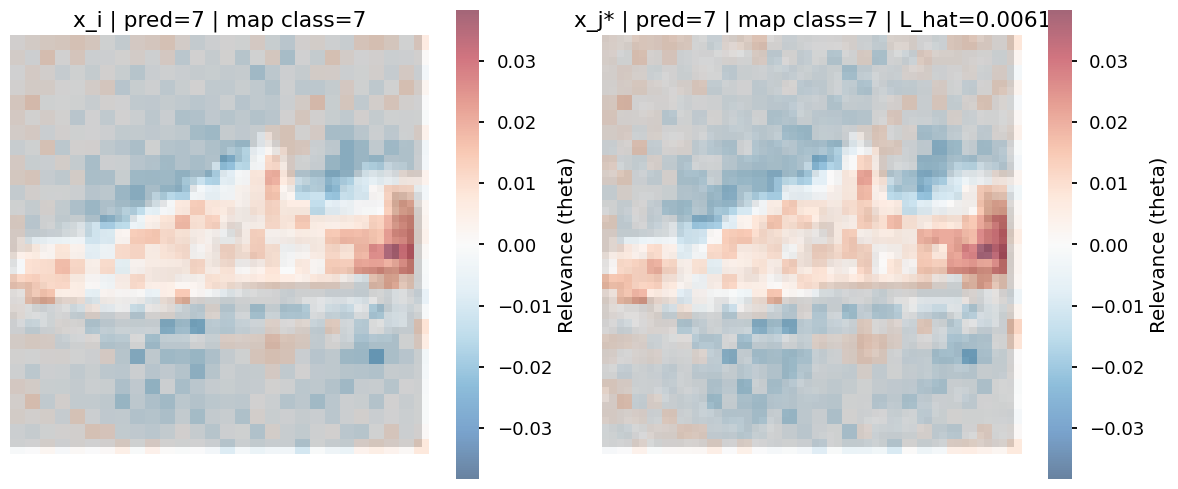

In [ ]:
plot_stability_comparison(
    model=model,
    x_i_norm=x_target,
    neighbors_norm=neighbors_norm,
    j_star=j_star,
    L_hat=L_hat,
    mean=MEAN,
    std=STD,
)